# Solar Capture Price — CAISO Exploration

This notebook walks through the solar capture price analysis interactively.
Run `download_data.py` and `process_data.py` first to populate `data/processed/market_data.csv`.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'figure.facecolor': '#FAFAF8',
    'axes.facecolor':   '#FAFAF8',
    'axes.grid':        True,
    'grid.color':       '#E8E6DF',
    'grid.linewidth':   0.7,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
})

ROOT = Path('..') 
df = pd.read_csv(ROOT / 'data/processed/market_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
print(f'Loaded {len(df)} rows, {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
df.head()

Loaded 744 rows, 2025-01-01 → 2025-02-01


,timestamp,np15_lmp,sp15_lmp,solar_mw,hub_avg_lmp
0,2025-01-01 08:00:00+00:00,42.15472,41.35992,0.0,41.757320
1,2025-01-01 09:00:00+00:00,42.20734,41.38941,0.0,41.798375
2,2025-01-01 10:00:00+00:00,41.85056,41.17314,0.0,41.511850
3,2025-01-01 11:00:00+00:00,41.39496,40.83716,0.0,41.116060
4,2025-01-01 12:00:00+00:00,42.16713,41.51501,0.0,41.841070


## 1. Headline metrics

In [2]:
total_gen     = df['solar_mw'].sum()
capture_price = (df['sp15_lmp'] * df['solar_mw']).sum() / total_gen
avg_lmp       = df['sp15_lmp'].mean()
capture_ratio = capture_price / avg_lmp
neg_exposure  = df.loc[df['sp15_lmp'] < 0, 'solar_mw'].sum() / total_gen

print(f'Solar capture price   : ${capture_price:.2f}/MWh')
print(f'Average SP15 LMP      : ${avg_lmp:.2f}/MWh')
print(f'Capture ratio         :  {capture_ratio:.1%}')
print(f'Value discount        :  {(1 - capture_ratio)*100:.1f}%')
print(f'Neg-price exposure    :  {neg_exposure:.1%}')

Solar capture price   : $17.43/MWh
Average SP15 LMP      : $41.35/MWh
Capture ratio         :  42.2%
Value discount        :  57.8%
Neg-price exposure    :  12.7%


## 2. Daily capture price vs average LMP

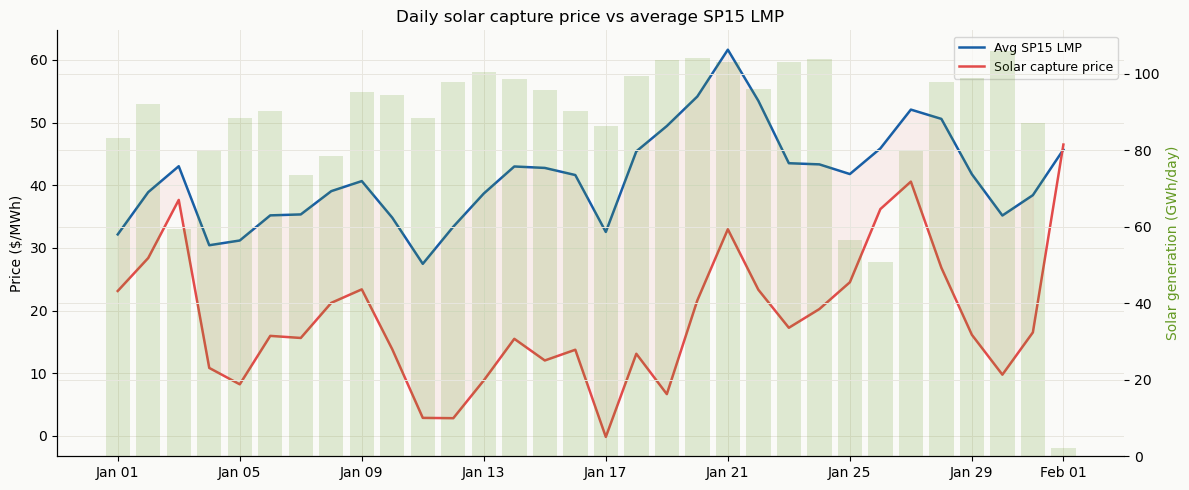

In [3]:
df['date'] = df['timestamp'].dt.date
daily = df.groupby('date').apply(
    lambda g: pd.Series({
        'capture_price': (g['sp15_lmp'] * g['solar_mw']).sum() / g['solar_mw'].sum(),
        'avg_lmp':       g['sp15_lmp'].mean(),
        'solar_gwh':     g['solar_mw'].sum() / 1000,
    })
).reset_index()
daily['date'] = pd.to_datetime(daily['date'])

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax2.bar(daily['date'], daily['solar_gwh'], color='#639922', alpha=0.18, width=0.8)
ax2.set_ylabel('Solar generation (GWh/day)', color='#639922', fontsize=10)
ax1.plot(daily['date'], daily['avg_lmp'],       '#185FA5', lw=1.8, label='Avg SP15 LMP')
ax1.plot(daily['date'], daily['capture_price'], '#E24B4A', lw=1.8, label='Solar capture price')
ax1.fill_between(daily['date'], daily['capture_price'], daily['avg_lmp'],
                 where=daily['avg_lmp'] > daily['capture_price'], alpha=0.07, color='#E24B4A')
ax1.set_ylabel('Price ($/MWh)')
ax1.legend(fontsize=9)
ax1.set_title('Daily solar capture price vs average SP15 LMP')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3. Duck curve — hourly price vs generation profile

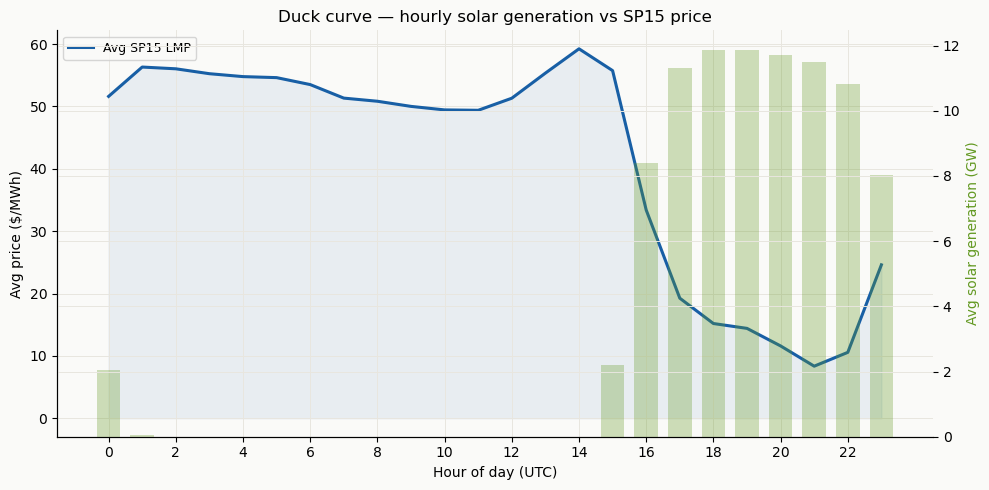

In [4]:
df['hour'] = df['timestamp'].dt.hour
hourly = df.groupby('hour').agg(avg_lmp=('sp15_lmp','mean'), avg_mw=('solar_mw','mean')).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax2.bar(hourly['hour'], hourly['avg_mw']/1000, color='#639922', alpha=0.3, width=0.7, label='Solar gen (GW)')
ax2.set_ylabel('Avg solar generation (GW)', color='#639922', fontsize=10)
ax1.plot(hourly['hour'], hourly['avg_lmp'], '#185FA5', lw=2.2, label='Avg SP15 LMP')
ax1.fill_between(hourly['hour'], hourly['avg_lmp'], alpha=0.08, color='#185FA5')
ax1.set_xlabel('Hour of day (UTC)')
ax1.set_ylabel('Avg price ($/MWh)')
ax1.set_xticks(range(0, 24, 2))
ax1.set_title('Duck curve — hourly solar generation vs SP15 price')
ax1.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

## 4. Price distribution — solar vs non-solar hours

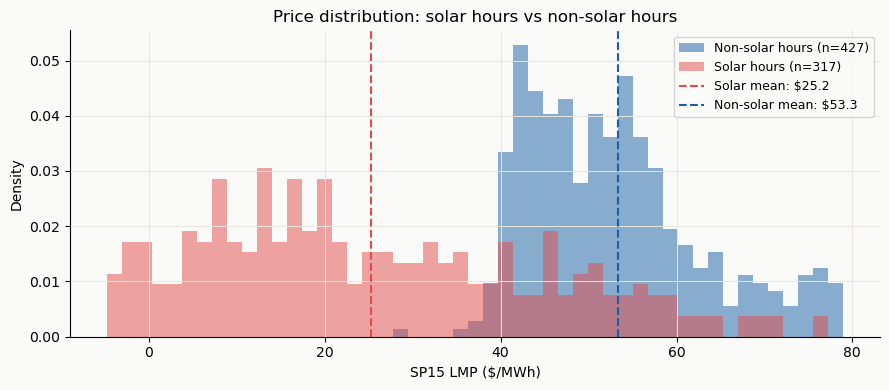

Solar hours avg price:     $25.24/MWh
Non-solar hours avg price: $53.30/MWh
Structural price gap:      $28.06/MWh


In [5]:
solar_hours    = df[df['solar_mw'] > 100]['sp15_lmp']
nonsolar_hours = df[df['solar_mw'] <= 100]['sp15_lmp']

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(df['sp15_lmp'].quantile(0.01), df['sp15_lmp'].quantile(0.99), 50)
ax.hist(nonsolar_hours, bins=bins, alpha=0.5, color='#185FA5', label=f'Non-solar hours (n={len(nonsolar_hours)})', density=True)
ax.hist(solar_hours,    bins=bins, alpha=0.5, color='#E24B4A', label=f'Solar hours (n={len(solar_hours)})',     density=True)
ax.axvline(solar_hours.mean(),    color='#E24B4A', lw=1.5, ls='--', label=f'Solar mean: ${solar_hours.mean():.1f}')
ax.axvline(nonsolar_hours.mean(), color='#185FA5', lw=1.5, ls='--', label=f'Non-solar mean: ${nonsolar_hours.mean():.1f}')
ax.set_xlabel('SP15 LMP ($/MWh)')
ax.set_ylabel('Density')
ax.set_title('Price distribution: solar hours vs non-solar hours')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f'Solar hours avg price:     ${solar_hours.mean():.2f}/MWh')
print(f'Non-solar hours avg price: ${nonsolar_hours.mean():.2f}/MWh')
print(f'Structural price gap:      ${nonsolar_hours.mean() - solar_hours.mean():.2f}/MWh')